In [2]:
import pandas as pd
df = pd.read_csv("loan_filtered.csv")
df.head(10)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,10+ years,RENT,24000.0,...,861.07,0.00,0.00,0.00,Jan-2016,0.0,0.0,0.0,0.0,32068.620045
1,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,< 1 year,RENT,30000.0,...,435.17,0.00,117.08,1.11,Sep-2013,0.0,0.0,0.0,0.0,32068.620045
2,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,10+ years,RENT,12252.0,...,603.65,0.00,0.00,0.00,Jan-2016,0.0,0.0,0.0,0.0,32068.620045
3,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,10+ years,RENT,49200.0,...,2209.33,16.97,0.00,0.00,Jan-2015,0.0,0.0,0.0,0.0,32068.620045
4,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,1 year,RENT,80000.0,...,1009.07,0.00,0.00,0.00,Jan-2016,0.0,0.0,0.0,0.0,32068.620045
5,5000.0,5000.0,5000.0,36 months,7.90,156.46,A,3 years,RENT,36000.0,...,631.38,0.00,0.00,0.00,Sep-2015,0.0,0.0,0.0,0.0,32068.620045
6,7000.0,7000.0,7000.0,60 months,15.96,170.08,C,8 years,RENT,47004.0,...,3025.99,0.00,0.00,0.00,Jan-2016,0.0,0.0,0.0,0.0,32068.620045
7,3000.0,3000.0,3000.0,36 months,18.64,109.43,E,9 years,RENT,48000.0,...,938.14,0.00,0.00,0.00,Dec-2014,0.0,0.0,0.0,0.0,32068.620045
8,5600.0,5600.0,5600.0,60 months,21.28,152.39,F,4 years,OWN,40000.0,...,294.94,0.00,189.06,2.09,Aug-2012,0.0,0.0,0.0,0.0,32068.620045
9,5375.0,5375.0,5350.0,60 months,12.69,121.45,B,< 1 year,RENT,15000.0,...,533.42,0.00,269.29,2.52,Mar-2013,0.0,0.0,0.0,0.0,32068.620045


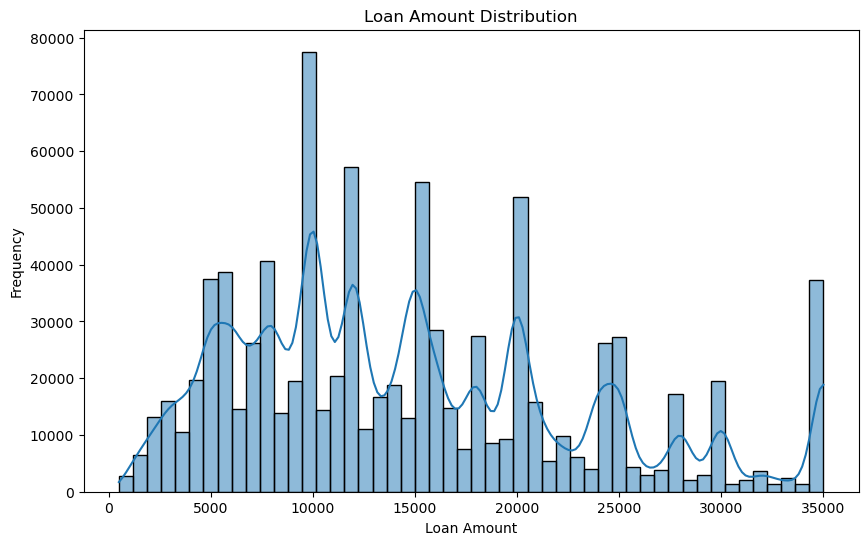

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


# 贷款金额分布的直方图
plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amnt'], bins=50, kde=True)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

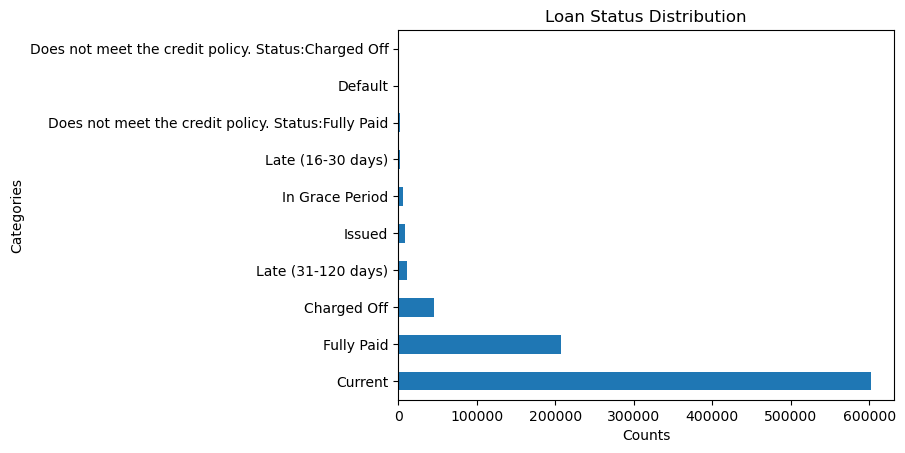

In [26]:
category_counts = df['loan_status'].value_counts()

# 创建横向条形图
category_counts.plot(kind='barh')

# 设置图表标题和坐标轴标签
plt.title('Loan Status Distribution')
plt.xlabel('Counts')
plt.ylabel('Categories')

plt.show()

In [ ]:
# ==================== 特征选择（Feature Selection） ====================
# 以下步骤从《1 数据初步清洗》notebook 移入，属于特征工程范畴：
# 1. 删除高基数列（id、url、emp_title 等标识符/近唯一列）
# 2. 删除类别严重不平衡列
# 3. 删除与信用评估无关或冗余的列
# 输入：loan_filtered.csv（52 列，仅完成缺失值处理）
# 输出：进入编码阶段的 df（40 列）
print(f"读入数据维度: {df.shape}")

In [ ]:
# 特征选择1：查看各非数值列的唯一值数量，识别高基数列
# （id、member_id、url、emp_title、title、zip_code 等唯一值极多，不具备预测能力）
non_float64_columns = df.select_dtypes(exclude=["float64"])
unique_counts = non_float64_columns.nunique()
print(unique_counts)

In [ ]:
# 删除唯一值 > 697 的高基数列
columns_to_drop = unique_counts[unique_counts > 697].index
df = df.drop(columns=columns_to_drop)
print(f"删除高基数列后维度: {df.shape}")
df.head()

In [ ]:
# 特征选择2：检查类别严重不平衡的列
print("pymnt_plan 分布:")
print(df.pymnt_plan.value_counts())
print()
print("application_type 分布:")
print(df.application_type.value_counts())

In [ ]:
# 特征选择3：删除冗余、不平衡、与信用评估无关的列
# - application_type、pymnt_plan：类别极度不平衡（>99.9% 为同一类别）
# - last_pymnt_amnt、last_pymnt_d：还款结果信息，与信用评估存在因果倒置
# - sub_grade：与 grade 高度冗余，保留 grade 即可
# - policy_code：只有唯一一个取值，不含任何信息
cols_to_drop = ["application_type", "pymnt_plan", "last_pymnt_amnt",
                "sub_grade", "policy_code", "last_pymnt_d"]
df = df.drop(columns=cols_to_drop)
print(f"特征选择完成后维度: {df.shape}")

In [3]:
# Data encoding1：将某些有顺序的类别变量重定义为定序变量
df['grade'] =df['grade'].replace({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
print(df.grade.value_counts())

df["home_ownership"] = df["home_ownership"].replace({"MORTGAGE":2,"RENT":3,"OWN":1,"OTHER":4,"NONE":5,"ANY":6})
print(df.home_ownership.value_counts())

df['verification_status']=df['verification_status'].replace({'Source Verified': 1,'Verified': 2,'Not Verified': 3,})
print(df.verification_status.value_counts())

df['loan_status'] = df['loan_status'].replace({'Fully Paid':1,
'Current':2,
'In Grace Period':3,
'Issued':4,
'Late (16-30 days)':5,
'Does not meet the credit policy. Status:Fully Paid':6,
'Late (31-120 days)':7,
'Default':8,
'Does not meet the credit policy. Status:Charged Off':9,
'Charged Off':10})
print(df.loan_status.value_counts())

df['initial_list_status']=df['initial_list_status'].replace({'f': 0,'w': 1})
print(df.initial_list_status.value_counts())

grade
2    254508
3    245843
1    148178
4    139534
5     70701
6     23045
7      5489
Name: count, dtype: int64
home_ownership
2    443529
3    356077
1     87461
4       182
5        46
6         3
Name: count, dtype: int64
verification_status
1    329542
2    291052
3    266704
Name: count, dtype: int64
loan_status
2     601750
1     207708
10     45242
7      11590
4       8460
3       6253
5       2357
6       1961
8       1219
9        758
Name: count, dtype: int64
initial_list_status
0    456787
1    430511
Name: count, dtype: int64


In [4]:
# 对数值+字符串的变量做一些处理
df['term'] = df['term'].str.split().str[0].astype(int)
df.term.value_counts()

term
36    621055
60    266243
Name: count, dtype: int64

In [5]:
df['emp_length'] = df['emp_length'].replace('< 1 year', '0.5 year')
df['emp_length'] = df['emp_length'].replace('10+ years', '10 year')
df['emp_length'] = df['emp_length'].str.split().str[0].astype(float)
df['emp_length'] = df['emp_length']
print(df.emp_length.value_counts())

emp_length
10.0    291547
2.0      78860
0.5      70581
3.0      70023
1.0      57089
5.0      55701
4.0      52529
0.0      44822
7.0      44591
8.0      43954
6.0      42947
9.0      34654
Name: count, dtype: int64


In [6]:
# 将日期变量转化为数值变量：与最近的日期之间的距离
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

# 找到参照日期（最近的日期）
reference_date = df['issue_d'].max()
df['issue_d'] = (reference_date.year - df['issue_d'].dt.year) * 12 + (reference_date.month - df['issue_d'].dt.month)
# 找到参照日期（最近的日期）
reference_date = df['last_credit_pull_d'].max()
df['last_credit_pull_d'] = (reference_date.year - df['last_credit_pull_d'].dt.year) * 12 + (reference_date.month - df['last_credit_pull_d'].dt.month)
# 找到参照日期（最近的日期）
reference_date = df['earliest_cr_line'].max()
df['earliest_cr_line'] = (reference_date.year - df['earliest_cr_line'].dt.year) * 12 + (reference_date.month - df['earliest_cr_line'].dt.month)

C:\Users\QQ\AppData\Local\Temp\ipykernel_5500\1788464036.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])
C:\Users\QQ\AppData\Local\Temp\ipykernel_5500\1788464036.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'])
C:\Users\QQ\AppData\Local\Temp\ipykernel_5500\1788464036.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


In [9]:
# 无法定序的类别变量用标签编码做处理（考虑到独热编码可能使模型解释性更强，但新增维数太多）
from sklearn.preprocessing import LabelEncoder

# 创建LabelEncoder的实例
label_encoder = LabelEncoder()

# 进行标签编码
df['purpose_'] = label_encoder.fit_transform(df['purpose'])
df['addr_state_'] = label_encoder.fit_transform(df['addr_state'])

df2 = df.drop(['purpose','addr_state'], axis=1)

# 查看转换后的数据
df[['purpose', 'purpose_', 'addr_state', 'addr_state_']]

,purpose,purpose_,addr_state,addr_state_
0,credit_card,1,AZ,3
1,car,0,GA,10
2,small_business,11,IL,14
3,other,9,CA,4
4,other,9,OR,37
...,...,...,...,...
887293,debt_consolidation,2,CA,4
887294,home_improvement,4,NJ,31
887295,debt_consolidation,2,TN,42
887296,debt_consolidation,2,MA,19


In [10]:
df2.head(10)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
0,5000.0,5000.0,4975.0,36,10.65,162.87,2,10.0,3,24000.0,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,1,3
1,2500.0,2500.0,2500.0,60,15.27,59.83,3,0.5,3,30000.0,...,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045,0,10
2,2400.0,2400.0,2400.0,36,15.96,84.33,3,10.0,3,12252.0,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,11,14
3,10000.0,10000.0,10000.0,36,13.49,339.31,3,10.0,3,49200.0,...,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045,9,4
4,3000.0,3000.0,3000.0,60,12.69,67.79,2,1.0,3,80000.0,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,9,37
5,5000.0,5000.0,5000.0,36,7.90,156.46,1,3.0,3,36000.0,...,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045,13,3
6,7000.0,7000.0,7000.0,60,15.96,170.08,3,8.0,3,47004.0,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,2,27
7,3000.0,3000.0,3000.0,36,18.64,109.43,5,9.0,3,48000.0,...,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045,0,4
8,5600.0,5600.0,5600.0,60,21.28,152.39,6,4.0,1,40000.0,...,189.06,2.09,41,0.0,0.0,0.0,0.0,32068.620045,11,4
9,5375.0,5375.0,5350.0,60,12.69,121.45,2,0.5,3,15000.0,...,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045,9,43


In [11]:
df2.corr()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
loan_amnt,1.000000,0.999263,0.997118,0.411718,0.145008,0.944973,0.150871,0.125951,-0.130710,0.332702,...,0.073158,0.052248,-0.074138,-0.016615,0.003946,-0.003504,0.330342,0.300224,-0.157058,0.015646
funded_amnt,0.999263,1.000000,0.998028,0.410761,0.145145,0.946001,0.150631,0.126129,-0.130749,0.332471,...,0.072695,0.051998,-0.077463,-0.016455,0.004051,-0.003473,0.331895,0.300421,-0.157986,0.015775
funded_amnt_inv,0.997118,0.998028,1.000000,0.411400,0.145183,0.943630,0.148654,0.127237,-0.131198,0.331430,...,0.070769,0.049457,-0.093483,-0.016018,0.004245,-0.003383,0.334618,0.299906,-0.160487,0.015978
term,0.411718,0.410761,0.411400,1.000000,0.428054,0.144974,0.442703,0.082169,-0.071090,0.058365,...,0.057290,0.035904,-0.058698,-0.005344,0.004943,-0.001986,0.114182,0.062387,-0.054738,0.024770
int_rate,0.145008,0.145145,0.145183,0.428054,1.000000,0.133058,0.954148,0.007791,0.046592,-0.072783,...,0.106860,0.070921,0.004688,0.013339,0.026479,0.001365,-0.074414,-0.160321,0.149784,0.006158
installment,0.944973,0.946001,0.943630,0.144974,0.133058,1.000000,0.129009,0.108106,-0.109037,0.326186,...,0.074563,0.054366,-0.059932,-0.014073,0.006580,-0.002802,0.300555,0.275401,-0.137893,0.008761
grade,0.150871,0.150631,0.148654,0.442703,0.954148,0.129009,1.000000,0.002581,0.042317,-0.064419,...,0.091282,0.064182,-0.006910,0.019736,0.027891,0.001855,-0.068249,-0.144735,0.150857,0.006729
emp_length,0.125951,0.126129,0.127237,0.082169,0.007791,0.108106,0.002581,1.000000,-0.136210,0.090683,...,0.006829,0.004282,-0.044227,-0.004048,0.008556,-0.000798,0.119950,0.074601,-0.019238,0.010367
home_ownership,-0.130710,-0.130749,-0.131198,-0.071090,0.046592,-0.109037,0.042317,-0.136210,1.000000,-0.092651,...,0.001069,-0.001124,0.022615,0.002730,-0.013490,-0.002103,-0.310643,-0.130413,0.013385,-0.071323
annual_inc,0.332702,0.332471,0.331430,0.058365,-0.072783,0.326186,-0.064419,0.090683,-0.092651,1.000000,...,0.007711,0.006640,-0.019579,-0.003923,0.014775,0.001234,0.399588,0.260474,0.006082,-0.004189


In [12]:
# 把与grade的相关性过高的列int_rate删去(事实上因果倒置)
df3 = df2.drop('int_rate', axis=1)

# 降维：由上面的相关矩阵可见loan_amnt、funded_amnt、funded_amnt_inv、installment有较强相关性，考虑只保留loan_amnt.
df3 = df3.drop(['funded_amnt_inv', 'installment', 'funded_amnt'], axis=1)
df3.head(10)

,loan_amnt,term,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,dti,...,recoveries,collection_recovery_fee,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,purpose_,addr_state_
0,5000.0,36,2,10.0,3,24000.0,2,48,1,27.65,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,1,3
1,2500.0,60,3,0.5,3,30000.0,1,48,10,1.00,...,117.08,1.11,28,0.0,0.0,0.0,0.0,32068.620045,0,10
2,2400.0,36,3,10.0,3,12252.0,3,48,1,8.72,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,11,14
3,10000.0,36,3,10.0,3,49200.0,1,48,1,20.00,...,0.00,0.00,12,0.0,0.0,0.0,0.0,32068.620045,9,4
4,3000.0,60,2,1.0,3,80000.0,1,48,2,17.94,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,9,37
5,5000.0,36,1,3.0,3,36000.0,1,48,1,11.20,...,0.00,0.00,4,0.0,0.0,0.0,0.0,32068.620045,13,3
6,7000.0,60,3,8.0,3,47004.0,3,48,2,23.51,...,0.00,0.00,0,0.0,0.0,0.0,0.0,32068.620045,2,27
7,3000.0,36,5,9.0,3,48000.0,1,48,1,5.35,...,0.00,0.00,13,0.0,0.0,0.0,0.0,32068.620045,0,4
8,5600.0,60,6,4.0,1,40000.0,1,48,10,5.55,...,189.06,2.09,41,0.0,0.0,0.0,0.0,32068.620045,11,4
9,5375.0,60,2,0.5,3,15000.0,2,48,10,18.08,...,269.29,2.52,34,0.0,0.0,0.0,0.0,32068.620045,9,43


In [20]:
# 将数据框写入新CSV文件
df3.to_csv('loan_encoded.csv', index=False)